In [1]:
import pandas as pd

data = {
    "Age": [19, 21, 20, 22, 18, 23, 21, 20, 19, 22],
    "Events_Attended": [8, 3, 10, 2, 7, 1, 9, 4, 11, 3],
    "Volunteer_Hours": [50, 15, 70, 10, 45, 5, 60, 20, 80, 18],
    "Social_Media_Shares": [15, 4, 20, 2, 12, 1, 18, 5, 22, 3],
    "Highly_Engaged": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

df

,Age,Events_Attended,Volunteer_Hours,Social_Media_Shares,Highly_Engaged
0,19,8,50,15,1
1,21,3,15,4,0
2,20,10,70,20,1
3,22,2,10,2,0
4,18,7,45,12,1
5,23,1,5,1,0
6,21,9,60,18,1
7,20,4,20,5,0
8,19,11,80,22,1
9,22,3,18,3,0


In [2]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


First 5 Rows:
   Age  Events_Attended  Volunteer_Hours  Social_Media_Shares  Highly_Engaged
0   19                8               50                   15               1
1   21                3               15                    4               0
2   20               10               70                   20               1
3   22                2               10                    2               0
4   18                7               45                   12               1

Dataset Shape:
(10, 5)

Column Names:
Index(['Age', 'Events_Attended', 'Volunteer_Hours', 'Social_Media_Shares',
       'Highly_Engaged'],
      dtype='object')


In [3]:
df.describe()


,Age,Events_Attended,Volunteer_Hours,Social_Media_Shares,Highly_Engaged
count,10.000000,10.000000,10.000000,10.00000,10.000000
mean,20.500000,5.800000,37.300000,10.20000,0.500000
std,1.581139,3.614784,27.051597,8.10761,0.527046
min,18.000000,1.000000,5.000000,1.00000,0.000000
25%,19.250000,3.000000,15.750000,3.25000,0.000000
50%,20.500000,5.500000,32.500000,8.50000,0.500000
75%,21.750000,8.750000,57.500000,17.25000,1.000000
max,23.000000,11.000000,80.000000,22.00000,1.000000


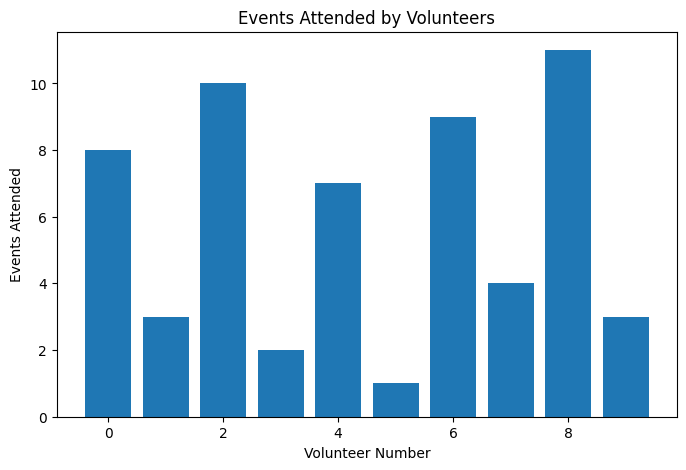

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(range(len(df)), df["Events_Attended"])

plt.title("Events Attended by Volunteers")
plt.xlabel("Volunteer Number")
plt.ylabel("Events Attended")

plt.show()


In [5]:
X = df[["Age", "Events_Attended", "Volunteer_Hours", "Social_Media_Shares"]]

y = df["Highly_Engaged"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Age  Events_Attended  Volunteer_Hours  Social_Media_Shares
0   19                8               50                   15
1   21                3               15                    4
2   20               10               70                   20
3   22                2               10                    2
4   18                7               45                   12

Target (y):
0    1
1    0
2    1
3    0
4    1
Name: Highly_Engaged, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8, 4)
Testing Data Shape: (2, 4)


In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
predictions = model.predict(X_test)

print("Predictions:")
print(predictions)

print("\nActual Values:")
print(y_test.values)

Predictions:
[1 0]

Actual Values:
[1 0]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


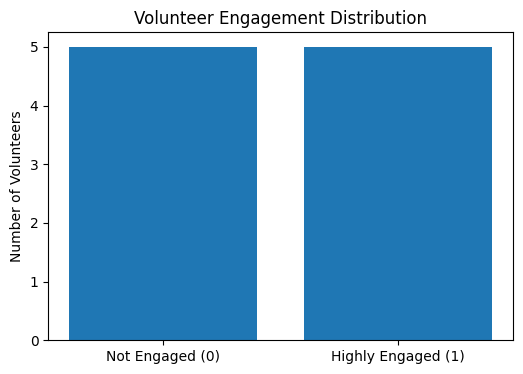

In [11]:
import matplotlib.pyplot as plt

engagement_counts = df["Highly_Engaged"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Not Engaged (0)", "Highly Engaged (1)"], engagement_counts)

plt.title("Volunteer Engagement Distribution")
plt.ylabel("Number of Volunteers")

plt.show()

In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

data = {
    "Age": np.random.randint(18, 26, n),
    "Events_Attended": np.random.randint(1, 15, n),
    "Volunteer_Hours": np.random.randint(5, 100, n),
    "Social_Media_Shares": np.random.randint(0, 30, n)
}

df = pd.DataFrame(data)

df["Highly_Engaged"] = (
    (df["Events_Attended"] > 7) &
    (df["Volunteer_Hours"] > 40)
).astype(int)

df.head()

,Age,Events_Attended,Volunteer_Hours,Social_Media_Shares,Highly_Engaged
0,24,2,17,24,0
1,21,10,36,24,0
2,22,12,75,17,1
3,24,2,63,22,0
4,20,10,90,29,1


In [13]:
df.shape

(100, 5)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Features and Target
X = df[["Age", "Events_Attended", "Volunteer_Hours", "Social_Media_Shares"]]
y = df["Highly_Engaged"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


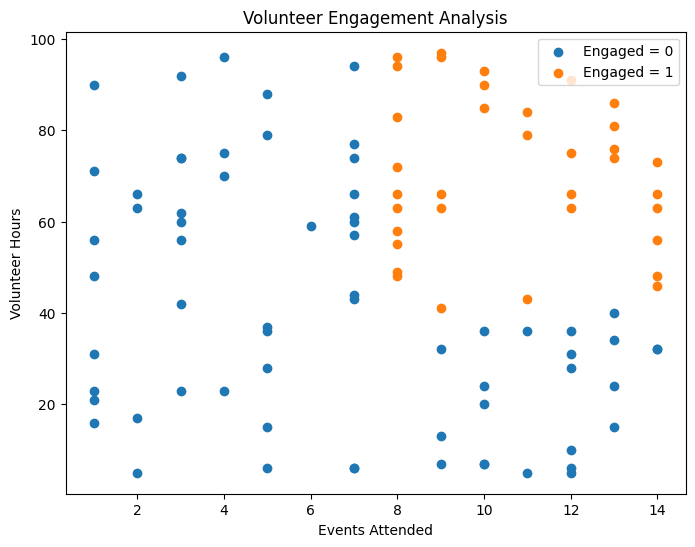

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for engagement in [0, 1]:
    subset = df[df["Highly_Engaged"] == engagement]

    plt.scatter(
        subset["Events_Attended"],
        subset["Volunteer_Hours"],
        label=f"Engaged = {engagement}"
    )

plt.xlabel("Events Attended")
plt.ylabel("Volunteer Hours")
plt.title("Volunteer Engagement Analysis")
plt.legend()

plt.show()

In [16]:
df.to_csv("volunteer_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [17]:
import os

os.listdir()

['.config', 'volunteer_data.csv', 'sample_data']

# Smart Volunteer Engagement Prediction System for NayePankh Foundation

## Objective
To analyze volunteer data and predict whether a volunteer is likely to be highly engaged using Machine Learning.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn

## Features
- Volunteer Data Analysis
- Data Visualization
- Engagement Prediction
- Machine Learning Model

In [18]:
from google.colab import files

files.download("volunteer_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>